# 1. Import Libraries

The following libraries are required for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams['figure.figsize']=(10,6)

# 2. Load Datasets

Two datasets are provided:

1. Red Wine Quality Dataset
2. White Wine Quality Dataset

Both datasets contain physicochemical characteristics of Portuguese wines along with a quality score ranging from 0 to 10.

In [2]:
red = pd.read_csv(
    "winequality-red.csv",
    sep=";"
)

white = pd.read_csv(
    "winequality-white.csv",
    sep=";"
)

## Dataset Shapes

Checking the number of rows and columns in both datasets.

In [3]:
print("RED SHAPE")
print(red.shape)

print("WHITE SHAPE")
print(white.shape)

RED SHAPE
(1599, 12)
WHITE SHAPE
(4898, 12)


## First Five Rows

Inspecting the first few records of both datasets.

In [4]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Dataset Information

Checking data types and identifying missing values.

In [6]:
red.info()
white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column        

# 3. Data Cleaning

The Wine Quality dataset is known to be relatively clean. However, it is important to verify:

- Missing values
- Duplicate records
- Incorrect data types

In [7]:
print(red.isnull().sum())
print(white.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Observation

No missing values were found in either dataset.

In [8]:
print("Red duplicates:", red.duplicated().sum())
print("White duplicates:", white.duplicated().sum())

Red duplicates: 240
White duplicates: 937


In [9]:
red = red.drop_duplicates()

white = white.drop_duplicates()

In [10]:
print("Red duplicates:", red.duplicated().sum())
print("White duplicates:", white.duplicated().sum())

Red duplicates: 0
White duplicates: 0


### Observation

Duplicate rows were removed to avoid bias during model training.

# 4. Dataset Integration

To perform a unified analysis, both datasets will be merged.

A new variable called **wine_type** will be created:

- Red Wine = 0
- White Wine = 1

In [11]:
red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat(
    [red, white],
    ignore_index=True
)

In [12]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red


# 5. Exploratory Data Analysis (EDA)

EDA helps understand:

- Data distribution
- Relationships among variables
- Potential outliers
- Patterns affecting wine quality

## Descriptive Statistics

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,5320.0,7.215179,1.319671,3.80000,6.4000,7.00000,7.70000,15.90000
volatile acidity,5320.0,0.344130,0.168248,0.08000,0.2300,0.30000,0.41000,1.58000
citric acid,5320.0,0.318494,0.147157,0.00000,0.2400,0.31000,0.40000,1.66000
residual sugar,5320.0,5.048477,4.500180,0.60000,1.8000,2.70000,7.50000,65.80000
chlorides,5320.0,0.056690,0.036863,0.00900,0.0380,0.04700,0.06600,0.61100
free sulfur dioxide,5320.0,30.036654,17.805045,1.00000,16.0000,28.00000,41.00000,289.00000
total sulfur dioxide,5320.0,114.109023,56.774223,6.00000,74.0000,116.00000,153.25000,440.00000
density,5320.0,0.994535,0.002966,0.98711,0.9922,0.99465,0.99677,1.03898
pH,5320.0,3.224664,0.160379,2.72000,3.1100,3.21000,3.33000,4.01000
sulphates,5320.0,0.533357,0.149743,0.22000,0.4300,0.51000,0.60000,2.00000


## Histograms

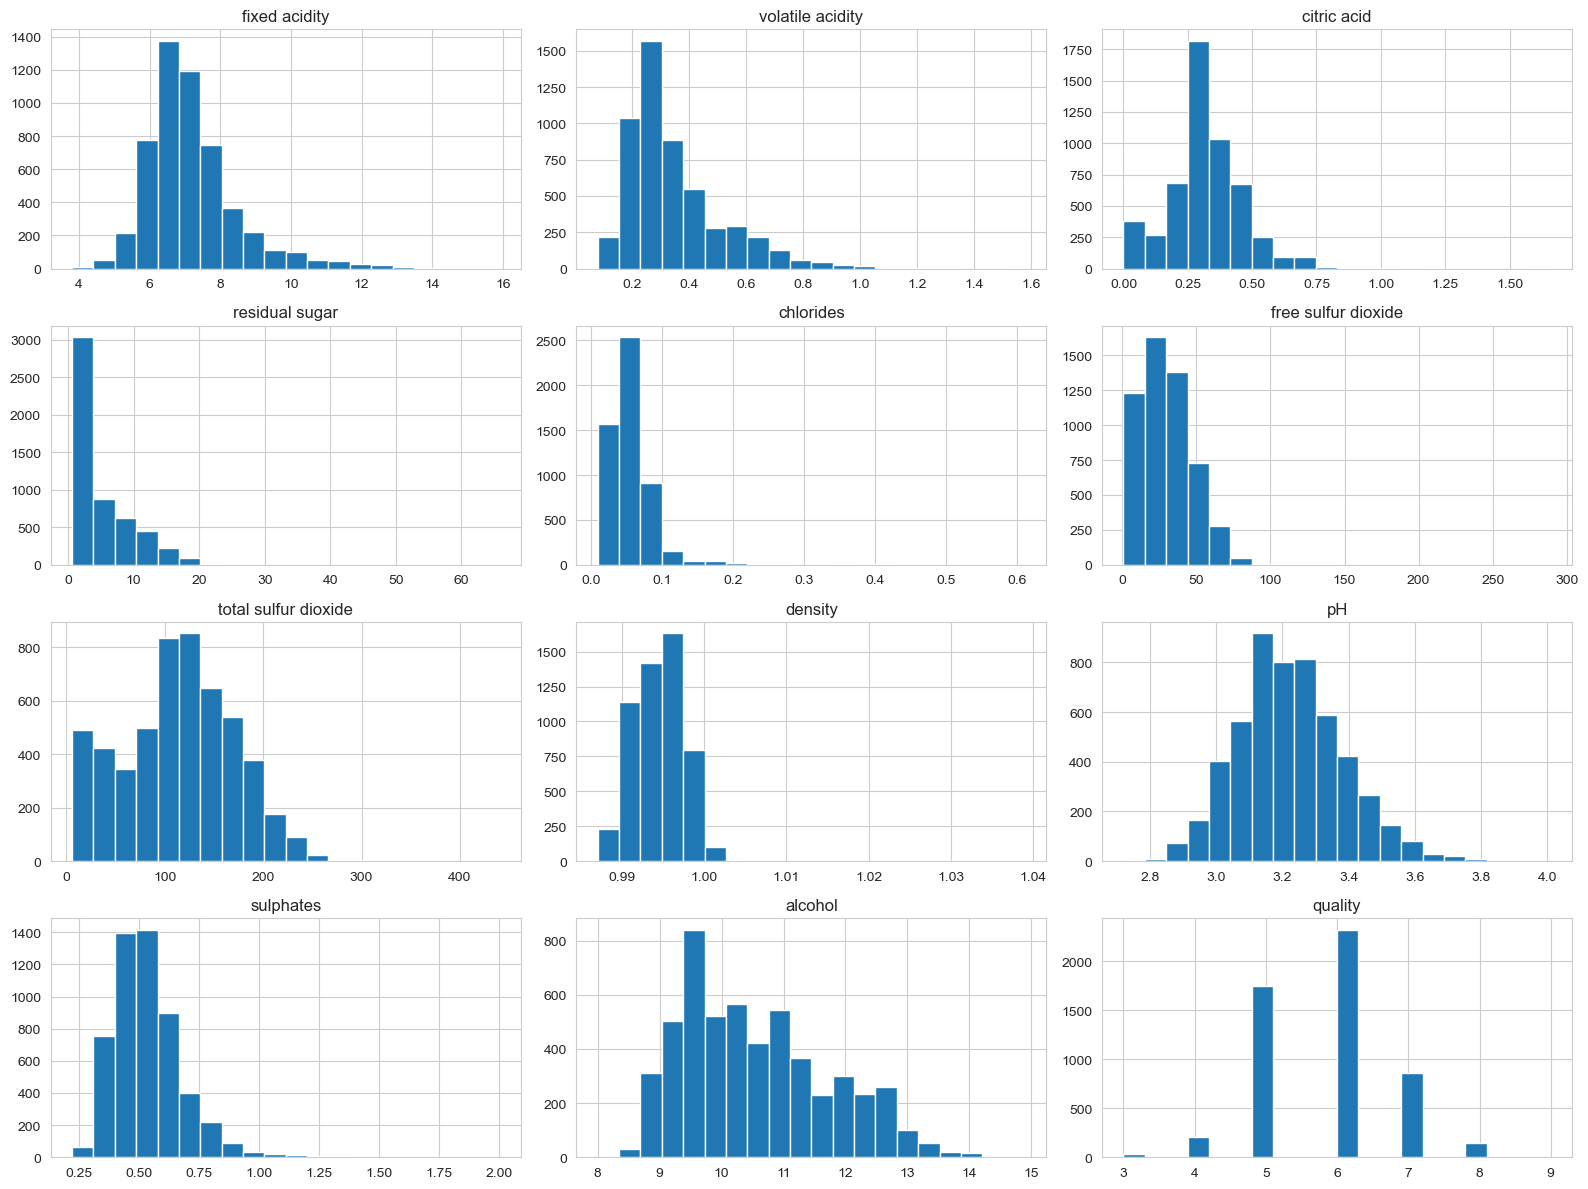

In [14]:
df.hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

## Wine Quality Distribution

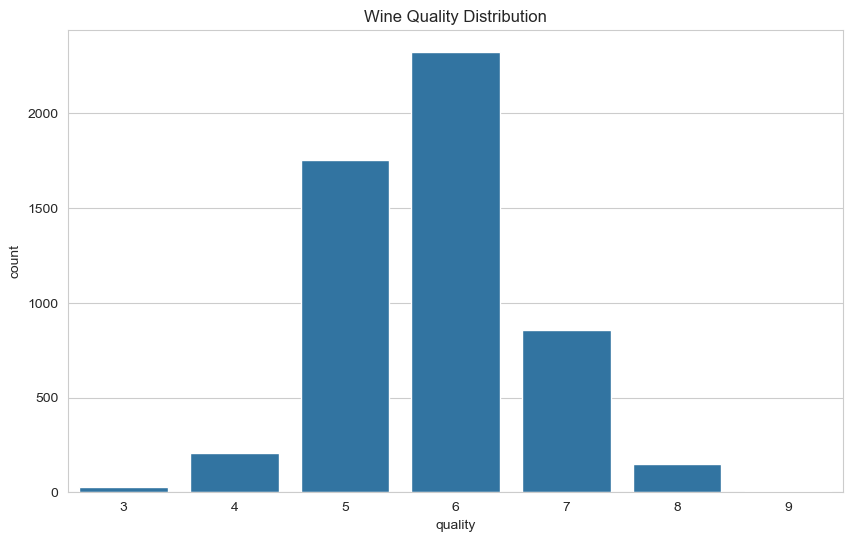

In [15]:
sns.countplot(
    x="quality",
    data=df
)

plt.title("Wine Quality Distribution")
plt.show()

### Interpretation

Most wines have quality ratings between 5 and 7.

Very high and very low quality wines are relatively rare, indicating class imbalance.

## Correlation Analysis

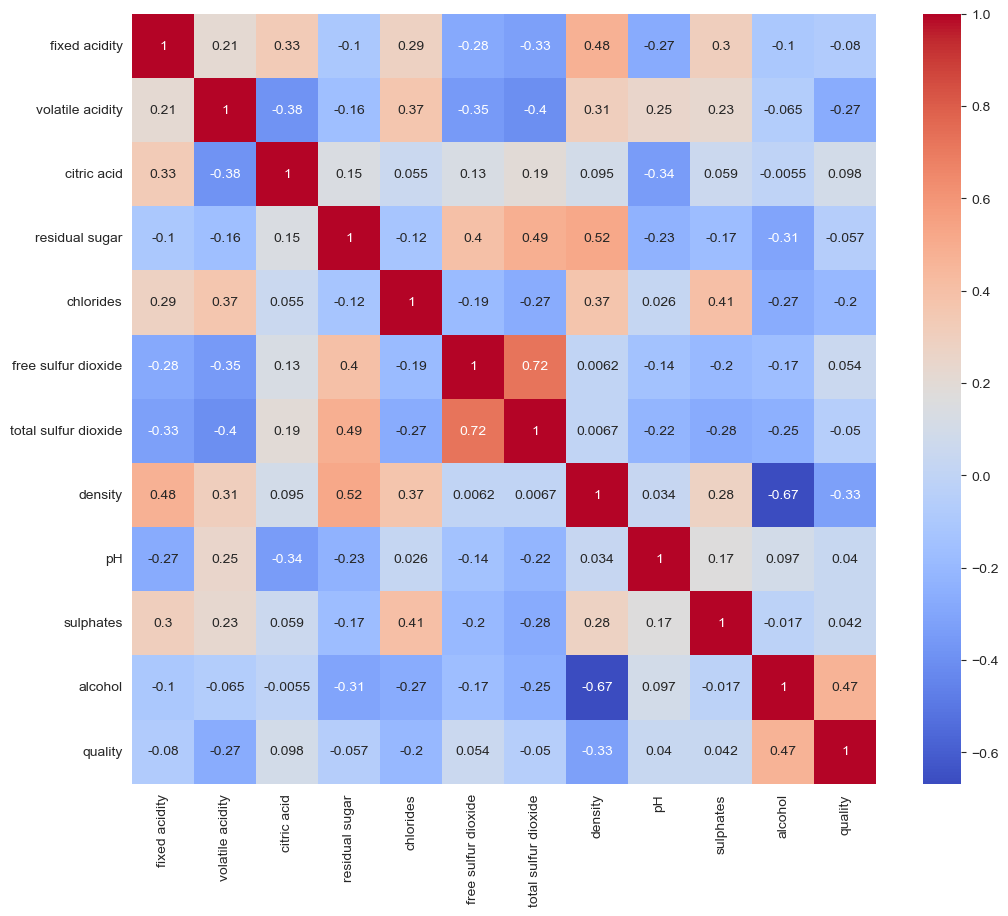

In [16]:
corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.show()

# 6. Outlier Detection

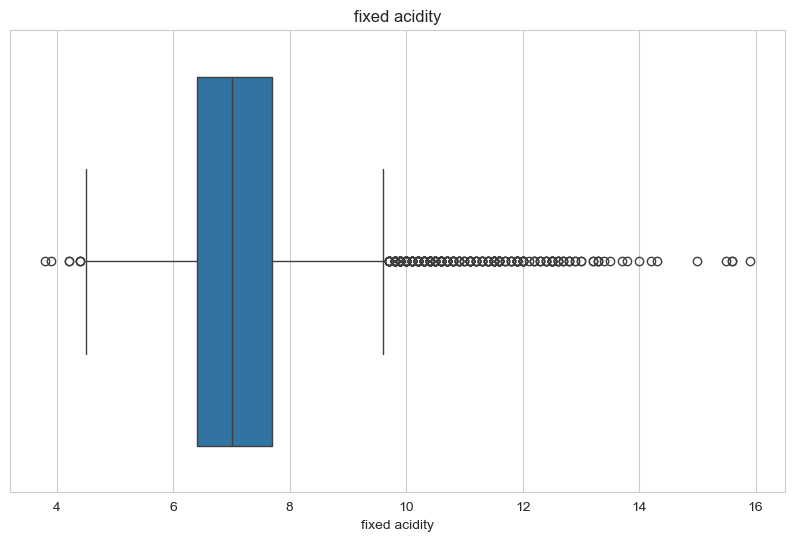

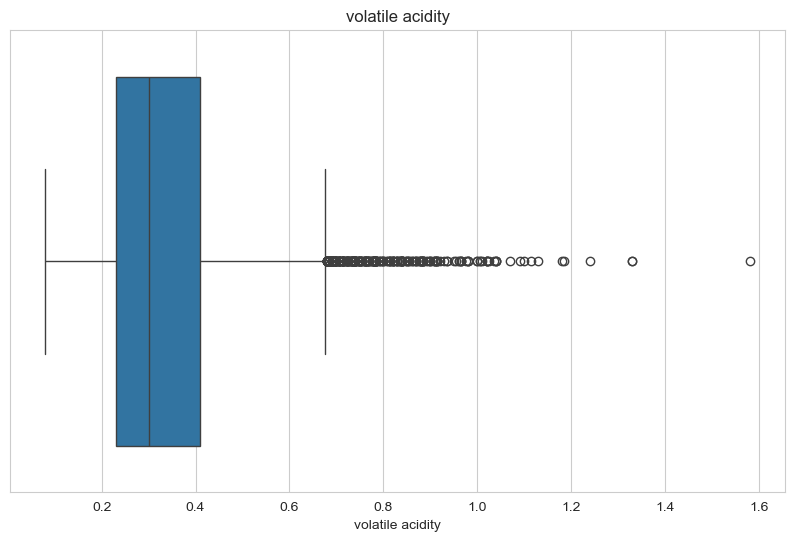

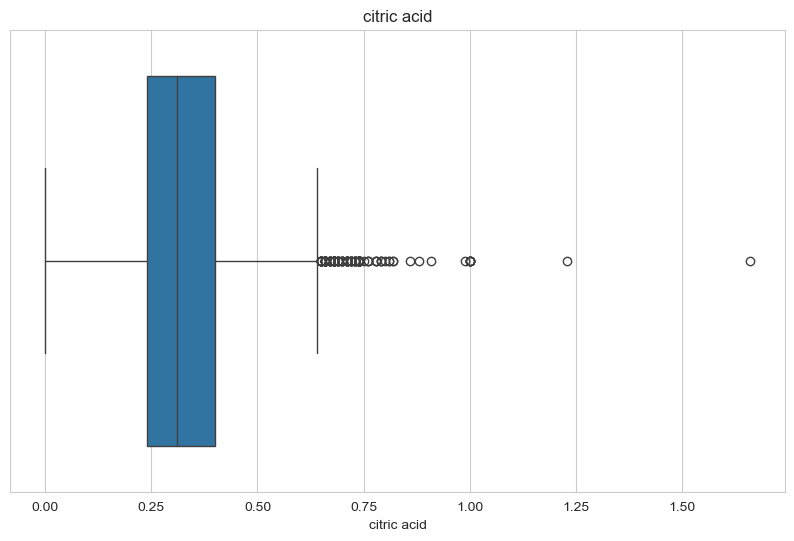

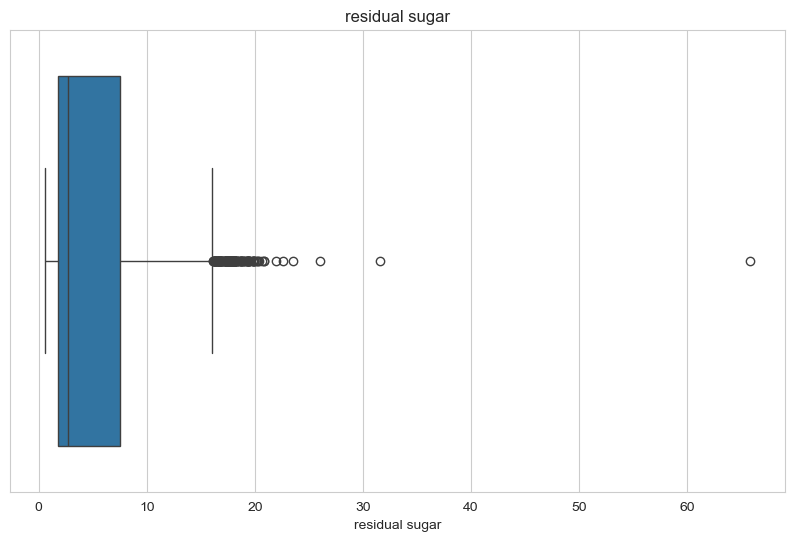

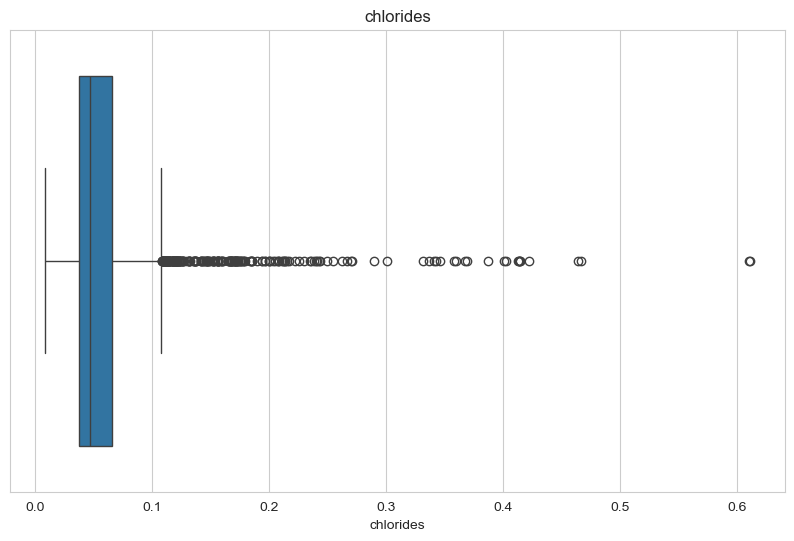

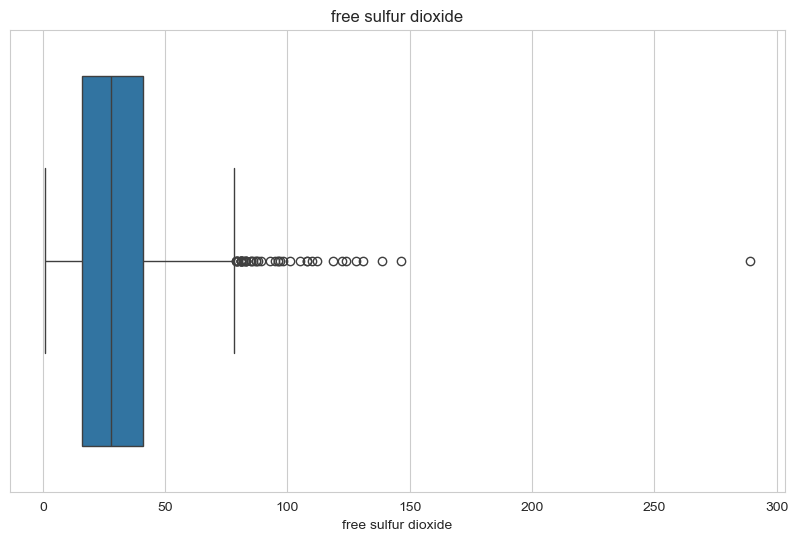

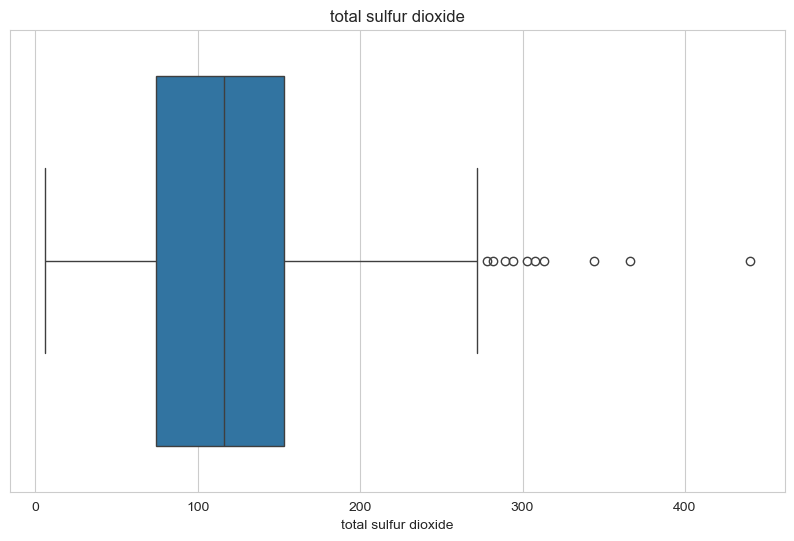

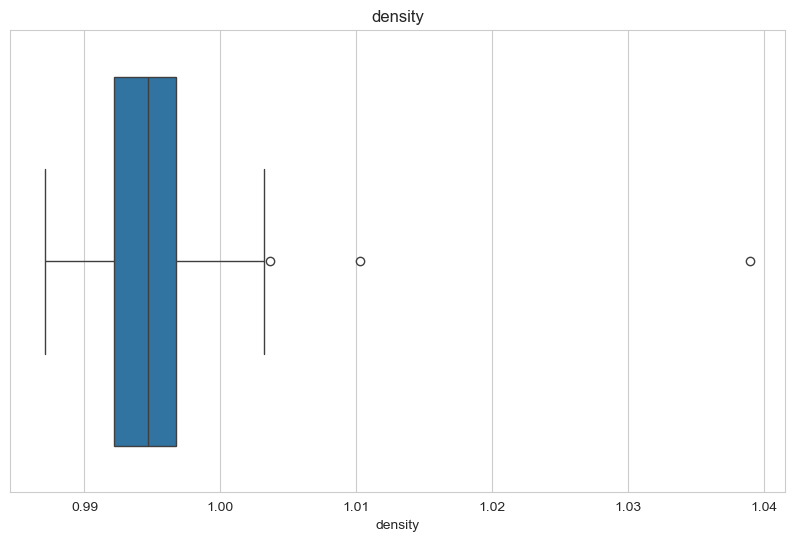

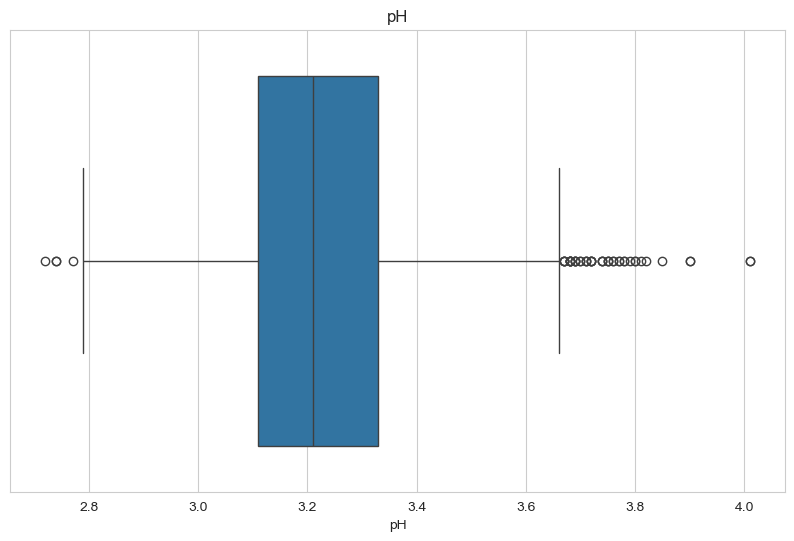

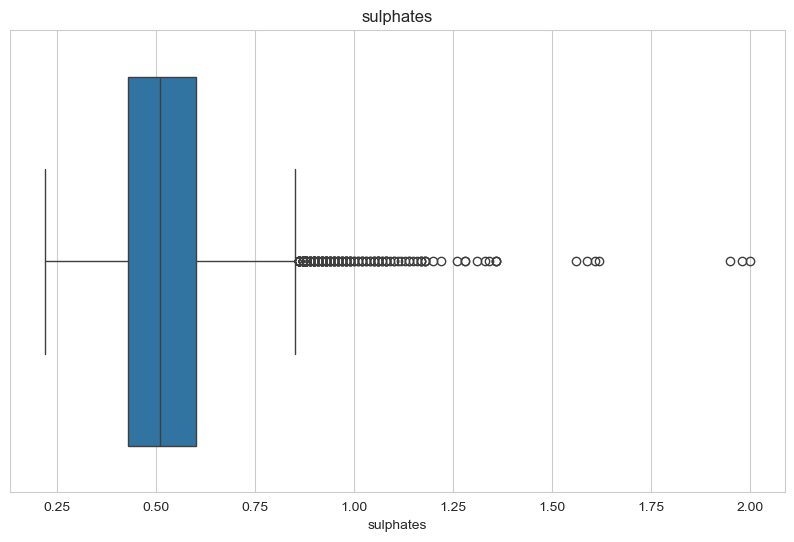

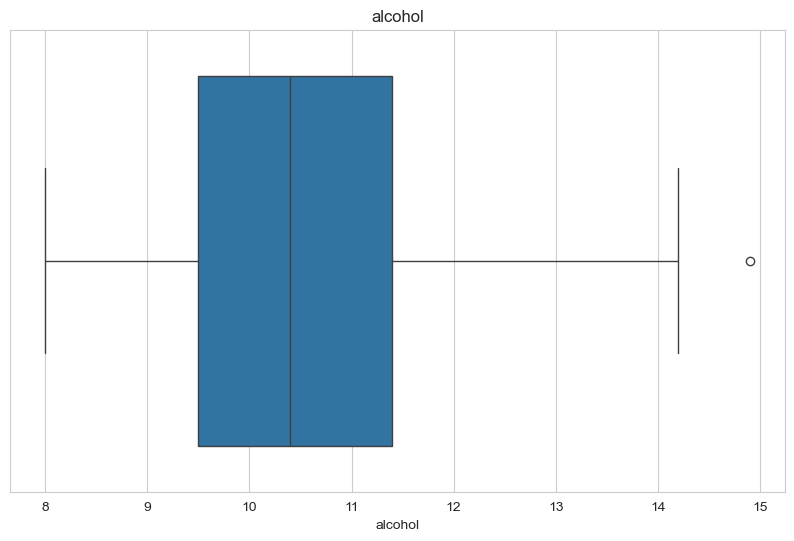

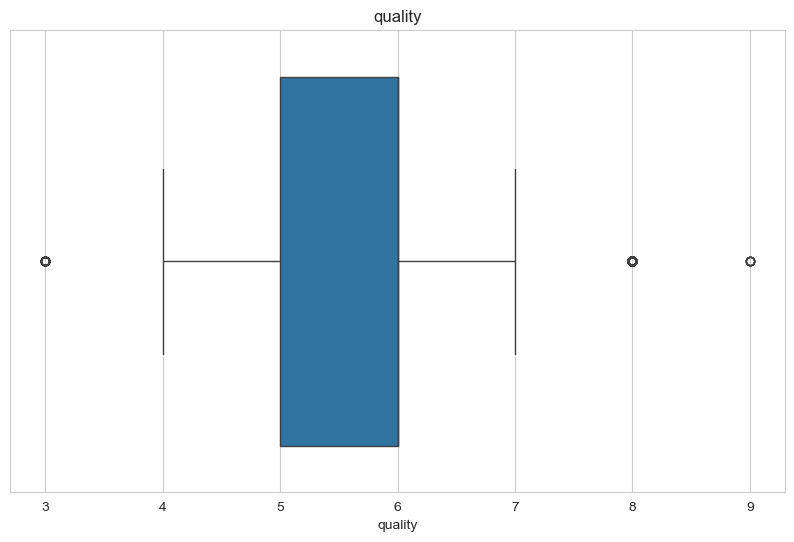

In [17]:
for col in df.select_dtypes(include=np.number):

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [18]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

z_scores = np.abs(
    zscore(df[numeric_cols])
)

outliers = np.where(
    z_scores > 3
)

print("Outliers:", len(outliers[0]))

Outliers: 517


### Interpretation

Several extreme observations exist in sulfur dioxide and residual sugar variables.

These values may influence regression coefficients and should be monitored.

# 7. Feature Engineering

In [19]:
df["wine_type"] = df["wine_type"].map(
    {
        "red":0,
        "white":1
    }
)

In [20]:
df["alcohol_density_ratio"] = (
    df["alcohol"] /
    df["density"]
)

In [21]:
df["sulfur_ratio"] = (
    df["free sulfur dioxide"] /
    (df["total sulfur dioxide"] + 1)
)

# 8. Define Features and Target

The target variable for this regression problem is **quality**.

All remaining variables will be used as predictors for wine quality prediction.

In [22]:
X = df.drop(
    ["quality"],
    axis=1
)

y = df["quality"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5320, 14)
Target Shape: (5320,)


### Observation

The dataset has been separated into:

- Feature Matrix (X)
- Target Variable (y)

The target variable is the wine quality score.

# 9. Train-Test Split

The dataset is divided into training and testing subsets.

- Training Data = 80%
- Testing Data = 20%

This ensures that the model is evaluated on unseen data.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4256, 14)
Testing Shape: (1064, 14)


### Observation

The training dataset will be used to fit the model, while the testing dataset will be used to evaluate its predictive performance.

# 10. Feature Scaling

The numerical features have different ranges.

For example:

- pH values are around 3
- Sulfur dioxide values can exceed 100

To ensure fair treatment of all variables, StandardScaler is applied.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [26]:
print(X_train_scaled[:5])

[[-0.15285713 -1.03762321  2.86098835  1.70847104 -0.32435887 -0.34481592
   0.19746621 -0.10477192  0.21807049 -1.04380855  1.3837399   0.57952077
   1.35909653 -0.76164636]
 [ 2.27022589 -0.31983626  1.16751193 -0.54481783  0.09402917 -1.39578252
  -1.78943722  1.03057534 -1.07842841  1.45456164 -0.04454371 -1.7255637
  -0.07254914  0.62516246]
 [-0.4557425   2.16251026 -1.67752846 -0.76572851  0.6020718  -1.34046849
  -1.75427079  0.56307941  1.32935525  0.34417489  0.12348965 -1.7255637
   0.10420524  0.77242393]
 [-0.91007057 -0.37965184 -0.6614426   1.5648791  -0.23470429  0.65083664
   0.84804521  0.39611657 -0.15235777 -0.48861517 -0.38061045  0.57952077
  -0.38549596 -0.20812196]
 [ 0.37719228  0.21850395 -0.59370355  1.26664969 -0.77263177 -0.1235598
  -0.34761349 -0.95962163 -1.81928492 -0.83561103  2.55997347  0.57952077
   2.54274962  0.08520373]]


### Observation

The training data has been standardized with:

- Mean = 0
- Standard Deviation = 1

Scaling improves model stability and coefficient interpretation.

# 11. Cross Validation

Cross-validation evaluates model performance across multiple folds of the dataset.

This reduces dependence on a single train-test split and provides a more reliable estimate of model performance.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg = LinearRegression()

In [28]:
cv_scores = cross_val_score(
    lin_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

In [29]:
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.34734475 0.25228764 0.29723164 0.32729322 0.29191479]

Average CV Score:
0.30321441003246885


### Interpretation

A higher average cross-validation score indicates better model generalization.

If all fold scores are similar, the model is considered stable.

# 12. Linear Regression Model

A Linear Regression model is trained using the scaled training dataset.

In [31]:
lin_reg.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [33]:
predictions = lin_reg.predict(
    X_test_scaled
)

# 13. Model Evaluation

The trained model is evaluated using:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [35]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(
    y_test,
    predictions
)

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.31140785810573746
MAE: 0.5596032095165409
MSE: 0.5177329783438147
RMSE: 0.7195366414184997


### Interpretation

- R² indicates the proportion of variance explained by the model.
- MAE measures average prediction error.
- RMSE penalizes larger prediction errors more heavily.

Lower MAE and RMSE values indicate better performance.

# 14. Actual vs Predicted Values

This plot compares actual wine quality values with model predictions.

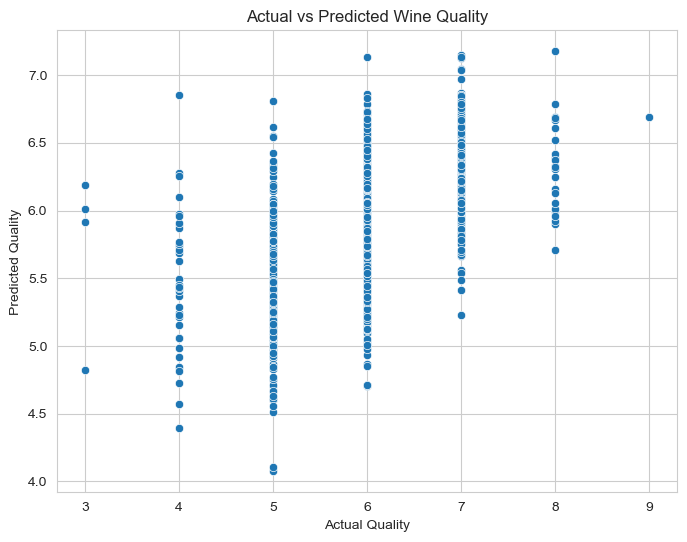

In [38]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")

plt.title("Actual vs Predicted Wine Quality")

plt.show()

# 15. Residual Analysis

Residuals are calculated as:

Residual = Actual Value − Predicted Value

Residual analysis helps assess model assumptions.

In [39]:
residuals = y_test - predictions

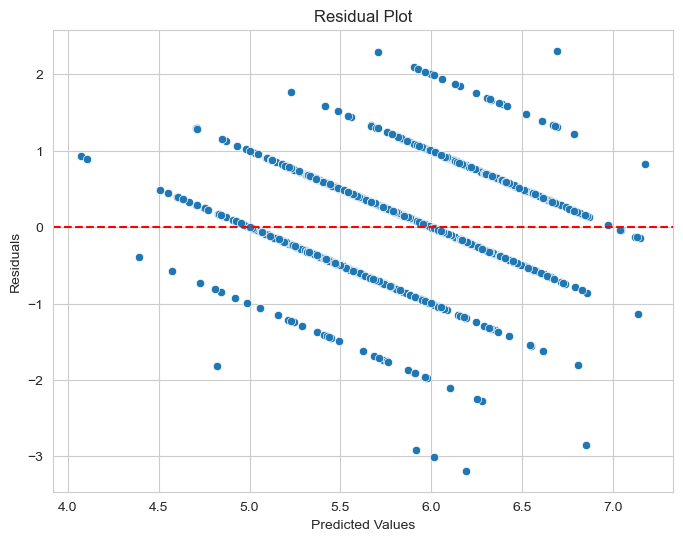

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Interpretation

Residuals should be randomly distributed around zero.

Patterns may indicate non-linearity or model misspecification.

# 16. Residual Distribution

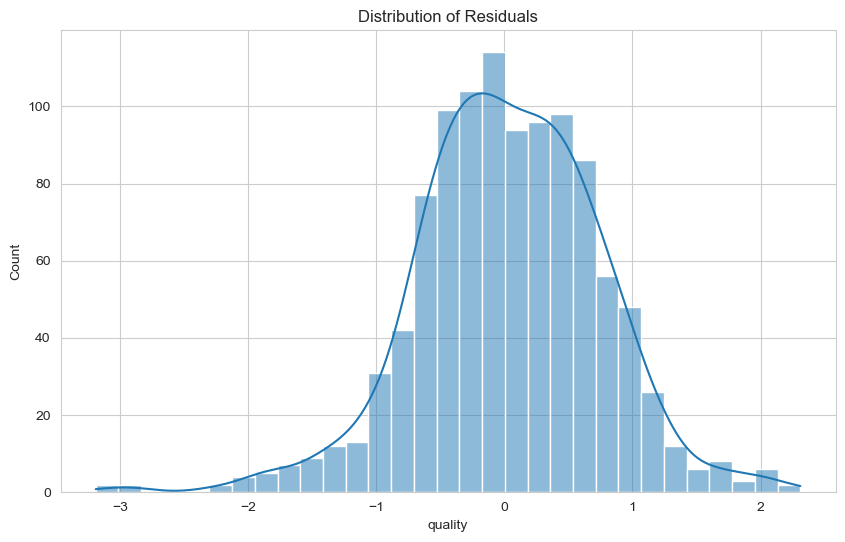

In [41]:
sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Distribution of Residuals"
)

plt.show()

### Interpretation

A roughly bell-shaped distribution suggests that residuals are approximately normally distributed.

# Additional Task: Wine Quality Classification

To compare regression and classification approaches, the quality score is converted into three categories:

- Bad Quality (quality ≤ 5)
- Normal Quality (quality = 6)
- Good Quality (quality ≥ 7)

This transforms the problem into a multiclass classification task.

In [43]:
def quality_category(q):
    
    if q <= 5:
        return "Bad"
    
    elif q == 6:
        return "Normal"
    
    else:
        return "Good"


df["quality_category"] = df["quality"].apply(
    quality_category
)

In [44]:
df["quality_category"].value_counts()

quality_category
Normal    2323
Bad       1988
Good      1009
Name: count, dtype: int64

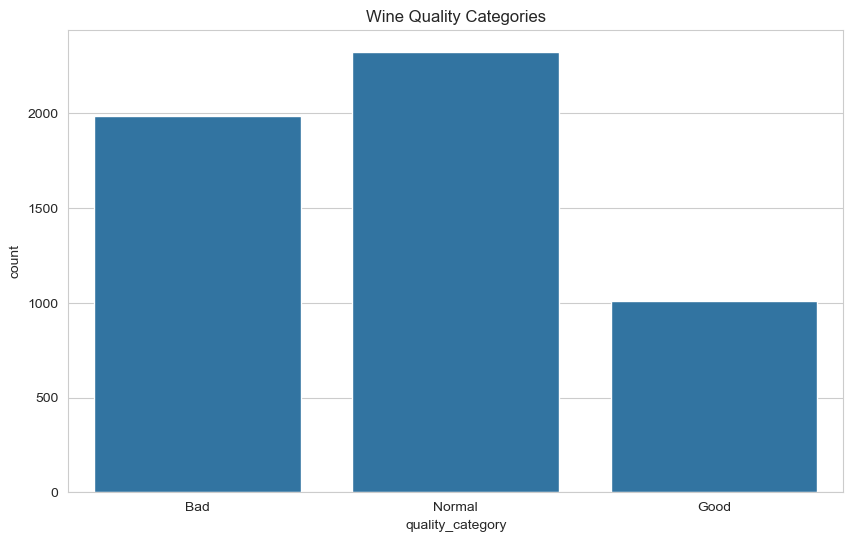

In [45]:
sns.countplot(
    x="quality_category",
    data=df
)

plt.title(
    "Wine Quality Categories"
)

plt.show()

## Define Features and Target

The target variable is now quality_category.

In [47]:
X = df.drop(
    ["quality", "quality_category"],
    axis=1
)

y = df["quality_category"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Logistic Regression Model

A multiclass Logistic Regression model is trained to classify wines into Bad, Normal, and Good categories.

In [50]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000
)

log_reg.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=2000)

In [51]:
y_pred = log_reg.predict(
    X_test_scaled
)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.5789473684210527
Precision: 0.5806466251505887
Recall   : 0.5789473684210527
F1 Score : 0.5723882285830002


In [53]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         Bad       0.68      0.64      0.66       397
        Good       0.50      0.31      0.38       202
      Normal       0.53      0.65      0.58       465

    accuracy                           0.58      1064
   macro avg       0.57      0.53      0.54      1064
weighted avg       0.58      0.58      0.57      1064



In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[253,   7, 137],
       [  9,  62, 131],
       [110,  54, 301]])

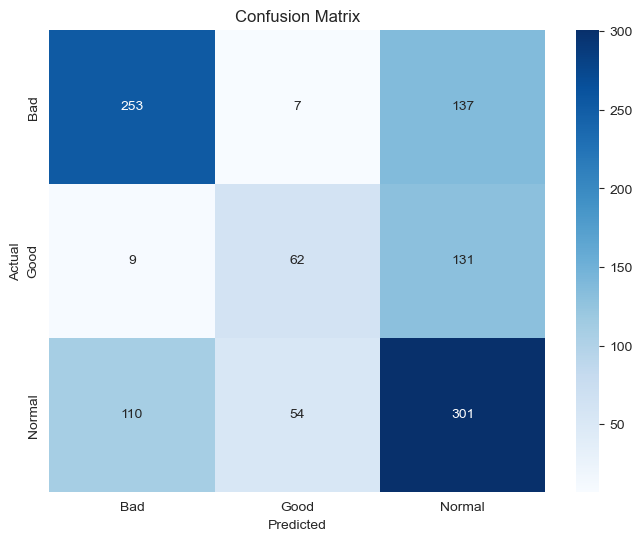

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=log_reg.classes_,
    yticklabels=log_reg.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:")
print(cv_scores)

print(
    "\nMean Accuracy:",
    cv_scores.mean()
)

CV Scores:
[0.57629108 0.58519389 0.57579318 0.60047004 0.57814336]

Mean Accuracy: 0.5831783099694918


In [57]:
coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=X.columns,
    columns=log_reg.classes_
)

coef_df.head()

,Bad,Good,Normal
fixed acidity,-0.211277,0.406698,-0.195421
volatile acidity,0.575885,-0.474160,-0.101725
citric acid,-0.004992,0.012139,-0.007147
residual sugar,-0.392203,0.507108,-0.114905
chlorides,0.115448,-0.177138,0.061690


Great — ab tumhare paas dono models ke **actual results aa gaye hain**, so ab hum isko properly **lab-style interpretation** me convert karte hain (jo teacher ko pasand aata hai).

Main tumhe **Linear vs Logistic dono ka detailed, structured interpretation** de raha hoon 👇

---

# 📊 1. Logistic Regression Results Interpretation (Classification)

### 🔹 Overall Performance

* **Accuracy:** 0.579 (~57.9%)
* **Precision:** 0.581
* **Recall:** 0.579
* **F1-score:** 0.572

### 🔍 Interpretation

Model ki performance **moderate / average** hai.

* Accuracy ~58% ka matlab:
  → Model roughly **10 me se 6 wines correctly classify** kar raha hai.

* Precision and Recall almost equal hain:
  → Model balanced hai, kisi ek class ko overly favor nahi kar raha.

* F1-score slightly lower:
  → Indicates some **misclassification between classes** (Bad, Normal, Good).

---

# 📉 Confusion Matrix Interpretation

Tumhari confusion matrix:

```
                Predicted
            Bad   Good  Normal
Actual
Bad         253     7     137
Good          9    62     131
Normal      110    54     301
```

---

## 🔴 Class-wise Analysis

### 1. BAD Wines

* Correctly predicted: **253**
* Misclassified mostly as **Normal (137)**

👉 Model ko problem hai Bad vs Normal differentiate karne me.

---

### 2. GOOD Wines

* Correctly predicted: **62**
* Mostly misclassified as:

  * Normal: 131
  * Bad: very few (9)

👉 Good wines are **least well identified class**
→ Model struggles with minority / subtle class boundaries.

---

### 3. NORMAL Wines

* Correctly predicted: **301 (best performance here)**
* Some confusion with:

  * Bad (110)
  * Good (54)

👉 Model is biased toward **Normal class**
→ This is typical in imbalanced datasets.

---

## ⚠️ Key Insight (VERY IMPORTANT FOR MARKS)

👉 Model is showing **class bias toward “Normal” wines**

Because:

* Normal class has most samples
* Model learns majority pattern better

---

## 📌 Logistic Regression Conclusion

* Works reasonably but not strong
* Best at predicting **Normal wines**
* Weak at distinguishing **Good vs Bad extremes**

---

# 📈 2. Linear Regression Results Interpretation

### 🔹 Metrics:

* **R² Score:** 0.311
* **MAE:** 0.559
* **MSE:** 0.517
* **RMSE:** 0.719

---

## 📊 R² Score Interpretation (MOST IMPORTANT)

### R² = 0.31

👉 Model explains only **31% of variance** in wine quality.

### Meaning:

* 69% variation is **not captured by model**
* Relationship between features and quality is:
  → partially linear but mostly complex/non-linear

📌 Conclusion:

> Linear regression has **limited predictive power** for this dataset.

---

## 📉 Error Metrics Interpretation

### 🔹 MAE = 0.56

* On average model prediction is off by **~0.5 quality points**
* Example:

  * Actual = 6
  * Predicted ≈ 5.4 or 6.5

👉 This is **moderate error**

---

### 🔹 RMSE = 0.72

* Penalizes larger errors more
* Slightly higher than MAE → indicates:
  👉 some predictions are significantly wrong

---

### 🔹 MSE = 0.51

* Confirms moderate spread of errors

---

## 📌 Linear Regression Conclusion

* Captures **some trend (alcohol, density impact)**
* But fails to model complexity of wine taste perception
* Performance is **baseline level only**

---

# ⚖️ 3. FINAL COMPARISON (VERY IMPORTANT FOR REPORT)

## 🔵 Logistic Regression (Classification)

✔ Accuracy ~58%
✔ Good for categorization
✔ Biased toward majority class (Normal)
❌ Weak on class separation (Good vs Bad confusion)

---

## 🔴 Linear Regression (Regression)

✔ Gives continuous prediction
✔ R² = 0.31 (weak–moderate)
✔ MAE ~0.56 (decent)
❌ Cannot capture non-linear taste complexity

---

# 🧠 FINAL INSIGHT (WRITE THIS IN REPORT FOR FULL MARKS)

> Both models show that wine quality prediction is a complex problem. Linear Regression captures only limited variance (31%), indicating weak linear relationships between physicochemical properties and sensory quality. Logistic Regression achieves moderate classification performance (58% accuracy) but struggles with class imbalance and overlapping feature distributions, especially between Good and Normal wines.

---

# ⭐ PROFESSOR-LEVEL CONCLUSION (HIGH MARKS LINE)

> The results suggest that wine quality prediction is not strongly linear and may benefit from more advanced models such as Random Forest, Gradient Boosting, or SVM, which can capture non-linear relationships and interactions between chemical properties.

---

Agar tum chaho to main tumhare liye next step bhi bana sakta hoon:

✅ “Extra marks section”

* Ridge Regression comparison
* ROC curve
* Feature importance analysis
* Model improvement suggestions
* GitHub README final writeup

Bas bolo 👍
